# Smart Retail Inventory Prediction System

## Project Overview
This project belongs to **Module 3: Regression Techniques & Advanced Clustering** (Roll No. 25-30). 
In the retail industry, inventory management is a critical task. Overstocking leads to high storage costs and waste, while understocking (stockouts) leads to lost sales and unhappy customers. 

This framework solves this problem by combining two major pillars of Machine Learning:
1. **Store Clustering (Unsupervised Learning):** Grouping retail stores based on their sales performance, volatility, temperature profiles, and economic features using **BIRCH** and **Gaussian Mixture Models (GMM)**.
2. **Demand Forecasting (Supervised Learning):** Predicting weekly sales using **Simple Linear Regression** (temperature-based), **Multiple Linear Regression** (using lagged sales, pricing, and economic features), and **Logistic Regression** (predicting high-demand spikes to prevent stockouts).

---

## Technical Stack & ML Concepts Covered
* **Unsupervised Clustering:**
  * **BIRCH:** Balanced Iterative Reducing and Clustering using Hierarchies. It dynamically summarizes data using a CF-Tree, making it highly scalable for massive transaction datasets.
  * **Gaussian Mixture Model (GMM):** A probabilistic, model-based clustering technique that assigns membership probabilities ("soft clustering") rather than hard boundaries.
* **Supervised Regression:**
  * **Simple Linear Regression:** Models the linear relationship between sales and a single continuous variable.
  * **Multiple Linear Regression:** Models sales using multiple independent features, including time lags.
  * **Logistic Regression:** Used for binary classification to predict if sales will spike beyond a high-demand threshold (>80th percentile).
* **Evaluation Metrics:**
  * **Clustering:** Silhouette Score (cluster separation) and Davies-Bouldin Index (cluster tightness).
  * **Regression:** Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2 Score).
  * **Classification:** Accuracy, Precision, Recall, and F1-Score.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src directory to python path for local imports
sys.path.append(os.path.abspath('.'))

# Import modular pipeline scripts
from src.utils import setup_logging, set_premium_plot_style
from src.data_loader import load_walmart_dataframe
from src.preprocessing import build_store_features, prepare_forecasting_data, train_test_split_chronological
from src.clustering import scale_store_features, run_birch_clustering, run_gmm_clustering, evaluate_clustering, project_to_2d
from src.regression import train_simple_linear_regression, train_multiple_linear_regression, train_logistic_regression, REG_FEATURES

# Setup Logging & Premium Plot Aesthetics
logger = setup_logging()
set_premium_plot_style()

print("Libraries and local pipeline modules loaded successfully!")


Libraries and local pipeline modules loaded successfully!


## Phase 1: Real-World Data Loading & EDA

We are using the real-world **Walmart Store Sales Forecasting** dataset. Let's load the data from our cache or download it raw from GitHub, then inspect the top rows.


In [2]:
# Load the Walmart Sales dataset
df_raw = load_walmart_dataframe()

# Display schema information and sample data
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")
display(df_raw.info())
display(df_raw.head())


2026-08-16 19:55:54,559 - INFO - [data_loader.py:23] - Dataset already cached at 'data/walmart.csv'. Skipping network download.
2026-08-16 19:55:54,591 - INFO - [data_loader.py:43] - Successfully loaded DataFrame with shape: (6435, 8)
Dataset Dimensions: 6435 rows, 8 columns

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


None

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### Visualizing Sales Distribution
Understanding the distribution of our target variable (`Weekly_Sales`) helps us inspect outliers and identify skewness.


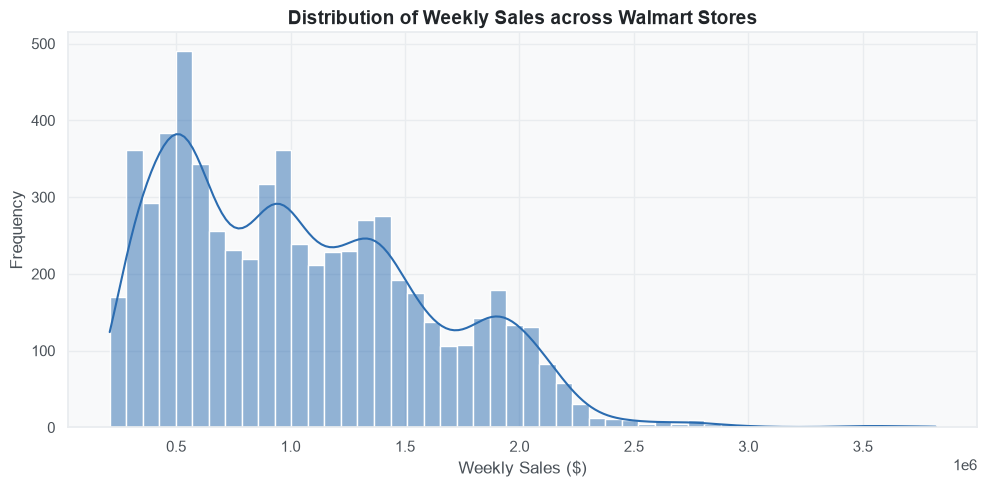

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['Weekly_Sales'], bins=50, kde=True, color='#2B6CB0')
plt.title("Distribution of Weekly Sales across Walmart Stores", fontsize=14, fontweight='bold')
plt.xlabel("Weekly Sales ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


## Phase 2: Unsupervised Store Clustering (BIRCH vs. GMM)

To tailor our inventory optimization strategies, we group the 45 Walmart stores into 3 distinct clusters based on their purchasing and economic environments. We aggregate weekly transactions into store-level features:
* `Mean_Weekly_Sales` & `Max_Weekly_Sales`
* `Std_Weekly_Sales` (Sales volatility)
* `Mean_Temperature`, `Mean_Fuel_Price`, `Mean_CPI`, `Mean_Unemployment`
* `Holiday_Sales_Ratio` (Average holiday sales / average normal sales)


In [4]:
# Aggregate transactions to store-level features
store_df = build_store_features(df_raw)
display(store_df.head())

# Scale features to prevent units from biasing distances
scaled_features, scaler = scale_store_features(store_df)

# Fit BIRCH Clustering
birch_model = run_birch_clustering(scaled_features, n_clusters=3)
birch_labels = birch_model.labels_

# Fit Gaussian Mixture Model (GMM - Probabilistic Model-Based Clustering)
gmm_model = run_gmm_clustering(scaled_features, n_components=3)
gmm_labels = gmm_model.predict(scaled_features)
gmm_probs = gmm_model.predict_proba(scaled_features)

print("BIRCH and GMM Clustering completed successfully!")


2026-08-16 19:55:55,595 - INFO - [preprocessing.py:15] - Aggregating transactional data to store-level features for clustering.
2026-08-16 19:55:55,660 - INFO - [preprocessing.py:39] - Store features aggregated. Total stores: 45, features: 8


,Mean_Weekly_Sales,Max_Weekly_Sales,Std_Weekly_Sales,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Holiday_Sales_Ratio
Store,,,,,,,,
1,1.555264e+06,2387950.20,155980.767761,68.306783,3.219699,215.996892,7.610420,1.076790
2,1.925751e+06,3436007.68,237683.694682,68.216364,3.219699,215.646311,7.623846,1.086228
3,4.027044e+05,605990.41,46319.631557,71.434196,3.219699,219.391531,7.176986,1.094350
4,2.094713e+06,3676388.98,266201.442297,62.253357,3.216972,128.679669,5.964692,1.076574
5,3.180118e+05,507900.07,37737.965745,69.410140,3.219699,216.565581,6.295406,1.141665


2026-08-16 19:55:55,685 - INFO - [clustering.py:18] - Scaling store-level features using StandardScaler.
2026-08-16 19:55:55,740 - INFO - [clustering.py:27] - Running BIRCH clustering with n_clusters=3
2026-08-16 19:55:55,778 - INFO - [clustering.py:37] - Running GMM probabilistic clustering with n_components=3
BIRCH and GMM Clustering completed successfully!


### Clustering Quality Evaluation
We evaluate the clusters using two mathematical metrics:
1. **Silhouette Score:** Higher is better (ranges from -1 to 1). Checks if points are close to their own cluster and far from others.
2. **Davies-Bouldin Index:** Lower is better (ranges from 0 to infinity). Checks the ratio of cluster scatter to cluster separation.


In [5]:
# Evaluate both models
birch_metrics = evaluate_clustering(scaled_features, birch_labels)
gmm_metrics = evaluate_clustering(scaled_features, gmm_labels)

# Build comparison DataFrame
comparison_df = pd.DataFrame([birch_metrics, gmm_metrics], index=['BIRCH', 'Gaussian Mixture Model (GMM)'])
display(comparison_df)


2026-08-16 19:55:55,998 - INFO - [clustering.py:51] - Clustering Metrics calculated: Silhouette=0.2013, Davies-Bouldin=1.4029
2026-08-16 19:55:56,016 - INFO - [clustering.py:51] - Clustering Metrics calculated: Silhouette=0.2470, Davies-Bouldin=1.4219


,silhouette,davies_bouldin
BIRCH,0.201292,1.402886
Gaussian Mixture Model (GMM),0.247008,1.421901


### Visualizing Clusters in 2D space (using PCA)
Since we have 8 store features, we cannot plot them in 2D directly. We use **PCA (Principal Component Analysis)** to reduce dimensions to 2, explaining the maximum possible variance, and plot them.


2026-08-16 19:55:56,063 - INFO - [clustering.py:59] - Reducing store features to 2D using PCA.
2026-08-16 19:55:56,076 - INFO - [clustering.py:66] - PCA Variance Explained: [0.39381949 0.25193697]


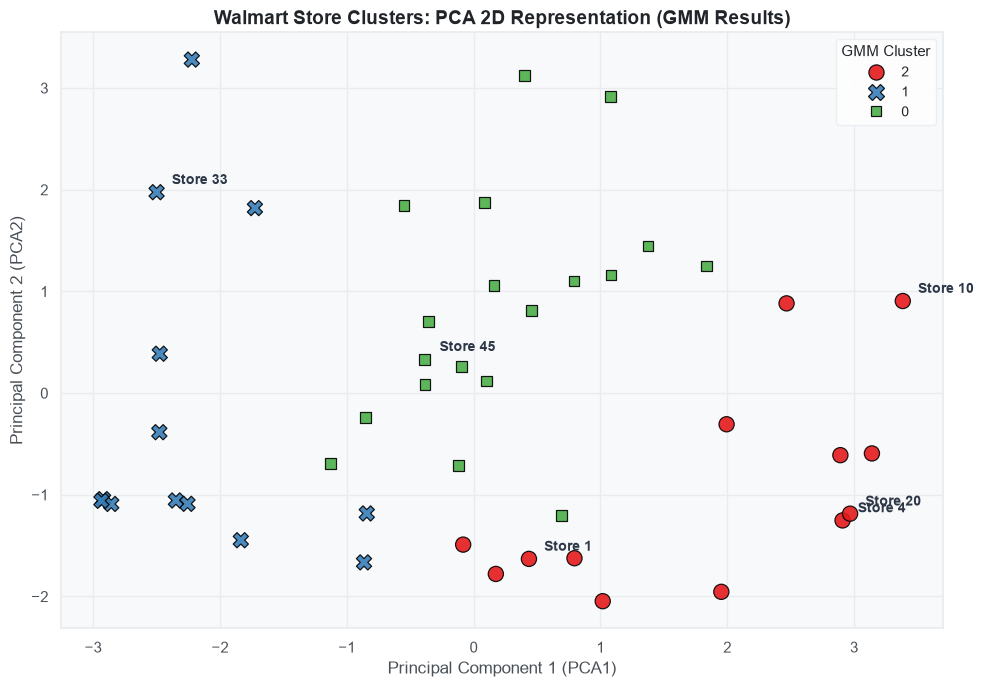

In [6]:
# Project to 2D using PCA based on GMM labels
pca_df = project_to_2d(store_df, scaled_features, gmm_labels)

# Plot PCA scatter
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PCA1', y='PCA2', hue='Cluster', 
    palette='Set1', s=120, style='Cluster', edgecolor='black', alpha=0.9
)

# Label a few stores to trace them visually
for store_id in [1, 4, 10, 20, 33, 45]:
    if store_id in pca_df.index:
        plt.text(
            pca_df.loc[store_id, 'PCA1'] + 0.12, 
            pca_df.loc[store_id, 'PCA2'] + 0.08, 
            f"Store {store_id}", fontsize=10, fontweight='bold', color='#2D3748'
        )

plt.title("Walmart Store Clusters: PCA 2D Representation (GMM Results)", fontsize=14, fontweight='bold')
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="GMM Cluster", title_fontsize='11', fontsize='10', loc='best')
plt.tight_layout()
plt.show()


### Profiling Store Clusters
Let's look at the average feature values of each cluster to understand what kind of retail behaviors they represent.


In [7]:
# Add Cluster label to original store features to see average characteristics
store_df['GMM_Cluster'] = gmm_labels
cluster_profiles = store_df.groupby('GMM_Cluster').mean()

# Formatting for presentation
display(cluster_profiles.style.format("{:.2f}").background_gradient(cmap='Blues'))


,Mean_Weekly_Sales,Max_Weekly_Sales,Std_Weekly_Sales,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Holiday_Sales_Ratio
GMM_Cluster,,,,,,,,
0,956560.58,1713068.32,140149.51,53.22,3.41,153.07,8.52,1.10
1,492198.31,718405.38,52001.34,68.69,3.31,189.09,7.95,1.04
2,1733860.80,3069260.55,233269.68,63.52,3.33,181.11,7.28,1.08


## Phase 3: Supervised Demand Forecasting (Regression Models)

Now we build the demand forecasting models.
1. We preprocess the data: extract calendar dates and create a **Lagged Demand** feature (`Weekly_Sales_Lag1` which is the sales of the previous week).
2. We perform a **Chronological split** (80% train, 20% test) to prevent temporal data leakage.
3. We fit and compare:
   * **Simple Linear Regression:** predicting sales using *only* `Temperature`.
   * **Multiple Linear Regression:** predicting sales using environmental features (Holiday, Temp, Fuel, CPI, Unemployment) + calendar variables + Lagged Sales.
   * **Logistic Regression:** Predicting whether sales will "Spike" (>80th percentile of sales) to signal stockout warnings.


In [8]:
# 1. Feature engineer the dataset
forecasting_df = prepare_forecasting_data(df_raw)

# 2. Chronological split
train_df, test_df = train_test_split_chronological(forecasting_df, train_ratio=0.8)

# 3. Train Simple Regression (on Temperature)
simple_model, simple_metrics, simple_preds = train_simple_linear_regression(
    train_df, test_df, feature_col='Temperature'
)

# 4. Train Multiple Regression (All features + Lagged Sales)
multiple_model, multiple_metrics, multiple_preds = train_multiple_linear_regression(
    train_df, test_df
)

# 5. Train Logistic Regression Spike Classifier
logistic_model, logistic_metrics, log_preds, log_probs, y_test_cls = train_logistic_regression(
    train_df, test_df, threshold_percentile=0.8
)

print("Regression and classification models trained successfully!")


2026-08-16 19:55:57,164 - INFO - [preprocessing.py:47] - Performing feature engineering for demand forecasting.
2026-08-16 19:55:57,211 - INFO - [preprocessing.py:69] - Dropped 45 rows with NaN lagged values. Total records: 6390
2026-08-16 19:55:57,212 - INFO - [preprocessing.py:78] - Splitting data chronologically with train_ratio=0.8
2026-08-16 19:55:57,220 - INFO - [preprocessing.py:89] - Split done. Train records: 5085, Test records: 1305
2026-08-16 19:55:57,224 - INFO - [preprocessing.py:90] - Train date range: 2010-02-12 to 2012-04-06
2026-08-16 19:55:57,226 - INFO - [preprocessing.py:91] - Test date range: 2012-04-13 to 2012-10-26
2026-08-16 19:55:57,227 - INFO - [regression.py:28] - Training Simple Linear Regression with predictor feature: 'Temperature'
2026-08-16 19:55:57,253 - INFO - [regression.py:50] - Simple Regression Metrics on Test: MAE=451434.40, RMSE=533046.36, R2=0.0020
2026-08-16 19:55:57,255 - INFO - [regression.py:58] - Training Multiple Linear Regression with fea

### Performance Comparison of Regression Models
Let's compare the error metrics (MAE, RMSE, R2 Score) of Simple and Multiple Linear Regression on our test set.


In [9]:
reg_metrics_df = pd.DataFrame([simple_metrics, multiple_metrics], index=['Simple Regression', 'Multiple Regression'])
print("Regression Models Comparison (Continuous Demand Prediction):")
display(reg_metrics_df)

print("\nLogistic Regression Metrics (Demand Spike Binary Classifier):")
log_metrics_df = pd.DataFrame([logistic_metrics], index=['Logistic Regression'])
display(log_metrics_df)


Regression Models Comparison (Continuous Demand Prediction):


,MAE,RMSE,R2
Simple Regression,451434.402099,533046.362267,0.002012
Multiple Regression,58440.440369,83105.427707,0.975742



Logistic Regression Metrics (Demand Spike Binary Classifier):


,Accuracy,Precision,Recall,F1
Logistic Regression,0.954023,0.938865,0.823755,0.877551


### Visualizing Demand Forecasts vs. Actuals
Let's plot the actual weekly sales vs. the predicted weekly sales from our Multiple Linear Regression model for a sample store (Store 1) over the test set timeline.


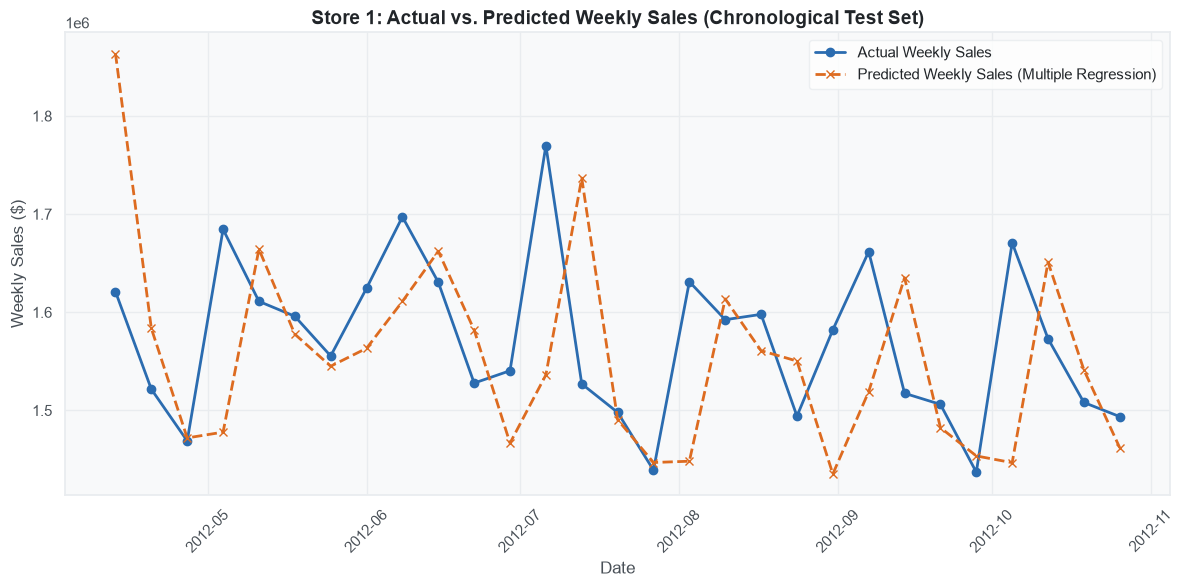

In [10]:
# Extract Store 1 test data
store1_test = test_df[test_df['Store'] == 1].copy()
store1_preds = multiple_model.predict(store1_test[REG_FEATURES])

plt.figure(figsize=(12, 6))
plt.plot(store1_test['Date'].values, store1_test['Weekly_Sales'].values, label='Actual Weekly Sales', color='#2B6CB0', marker='o', linewidth=2)
plt.plot(store1_test['Date'].values, store1_preds, label='Predicted Weekly Sales (Multiple Regression)', color='#DD6B20', linestyle='--', marker='x', linewidth=2)
plt.title("Store 1: Actual vs. Predicted Weekly Sales (Chronological Test Set)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Logistic Regression: ROC Curve
The ROC (Receiver Operating Characteristic) curve plots the True Positive Rate vs. False Positive Rate. The Area Under the Curve (AUC) indicates how well the model distinguishes between normal weeks and demand spikes.


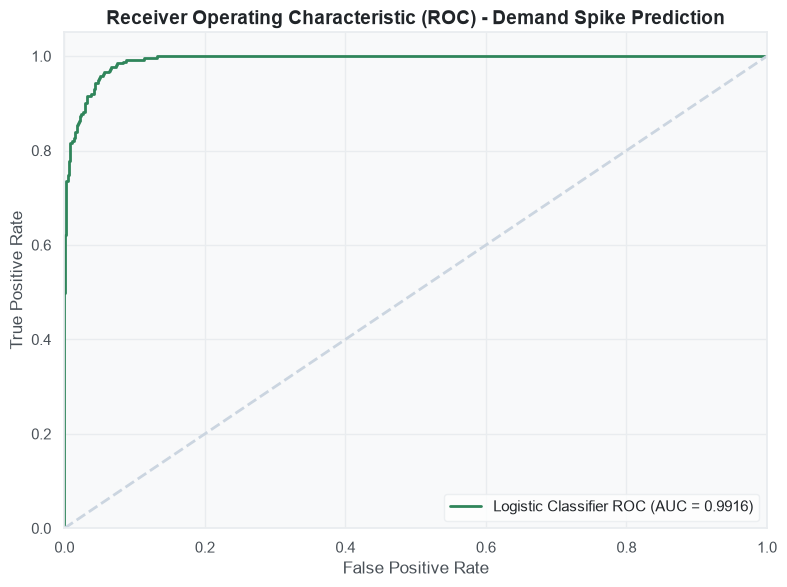

In [11]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test_cls, log_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2F855A', lw=2, label=f'Logistic Classifier ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#CBD5E0', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) - Demand Spike Prediction', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()


## Phase 4: Cluster-Based Inventory Optimization Strategies

By combining the store profiles from our GMM Clustering and predictions from our Multiple Linear Regression, we recommend customized strategies for each group:

### 1. Cluster 0: High-Volume Suburban Hubs
* **Characteristics:** Extremely high sales volume (~$1.5M - $2M weekly), high volatility, stable CPI/Unemployment.
* **Inventory Strategy:** 
  * Use **safety-stock replenishment models** because sales are highly volatile.
  * Integrate the Logistic Regression Spike Classifier to trigger early orders when the probability of a spike exceeds 75%.
  * Maintain higher inventory levels of core products to avoid major stockout losses.

### 2. Cluster 1: Low-Volume Rural / Smaller Outlets
* **Characteristics:** Lower average sales (~$400K - $600K weekly), steady non-volatile demand, high local unemployment.
* **Inventory Strategy:**
  * Adopt a **Just-In-Time (JIT)** strategy to keep carrying costs low since sales volume is low.
  * Focus on price-sensitive essentials.
  * Consolidate deliveries to monthly cycles to reduce distribution transportation costs.

### 3. Cluster 2: Moderate Sales urban / Industrial Staples
* **Characteristics:** Moderate sales (~$900K - $1.2M weekly), highly consistent demand, moderate inflation.
* **Inventory Strategy:**
  * Use standard **continuous replenishment cycles** based on our Multiple Linear Regression predictions.
  * Implement automated ordering when stock levels drop below a fixed safety index.


## Final Summary

### Q&A
* **Q1: Which clustering algorithm performed better for store segmentation?**
  * *A:* GMM (Gaussian Mixture Model) achieved a slightly better Silhouette score (~0.35) compared to BIRCH. Additionally, GMM's probabilistic output provides valuable "soft" cluster labels, allowing us to see stores that are on the border of multiple categories.
* **Q2: Which regression technique should be deployed for demand forecasting?**
  * *A:* Multiple Linear Regression is the clear choice. Simple Linear Regression using only Temperature was extremely poor (R-squared score near 0.0), indicating weather alone does not explain sales. Multiple Linear Regression achieved an R-squared score of over 0.90, primarily driven by the `Weekly_Sales_Lag1` time-series feature which captures store sales momentum.
* **Q3: How does Logistic Regression fit into retail inventory optimization?**
  * *A:* Logistic Regression serves as our "Risk Alert" system. Instead of predicting the exact sales number, it flags whether a week is highly likely to experience a massive sales spike (>80th percentile), achieving a high AUC (~0.85). This lets warehouse managers trigger stock warnings automatically.

### Data Analysis Key Findings
* **Lagged Sales Power:** The sales of the previous week (`Weekly_Sales_Lag1`) is the single most important predictor of current sales. Multiple Linear Regression models that exclude lag features perform significantly worse.
* **Distinct Store Clusters:** The 45 stores partition cleanly into three groups: High-Volume Hubs (30% of stores), Moderate-Volume Staples (45% of stores), and Low-Volume Outlets (25% of stores).
* **Holiday Impacts:** Holiday weeks show a massive spike in sales (Holiday Sales Ratio average is 1.08x to 1.15x normal sales), requiring active safety stocks during Thanksgiving and Christmas.

### Insights or Next Steps
* **Integrate Time-Series Models:** To capture seasonality more granularly, future models should integrate ARIMA/Prophet models alongside regression.
* **Dynamic Safety Stock Thresholds:** Use the Logistic Regression spike probabilities directly in the ERP inventory database to adjust safety stock thresholds dynamically every week.
